In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
np.random.seed(318)


In [2]:
def himmelblau(x):
    x1, x2 = x
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

bounds = [(-6, 6), (-6, 6)]

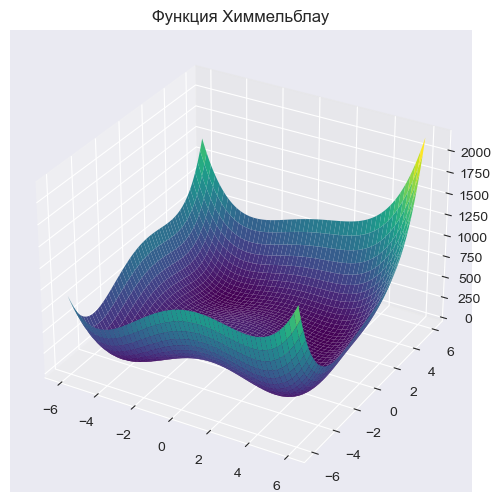

In [3]:
x = np.linspace(-6, 6, 400)
y = np.linspace(-6, 6, 400)
X, Y = np.meshgrid(x, y)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0)
ax.set_title("Функция Химмельблау")
plt.show()

In [4]:
def run_bfgs(n_runs=100):
    vals, times_ = [], []
    for _ in range(n_runs):
        x0 = np.random.uniform(-6, 6, 2)
        t0 = time.time()
        res = minimize(himmelblau, x0, method='BFGS')
        t1 = time.time()
        vals.append(res.fun)
        times_.append(t1 - t0)
    return np.array(vals), np.array(times_)

bfgs_vals, bfgs_times = run_bfgs()
print("BFGS mean =", np.mean(bfgs_vals), " var =", np.var(bfgs_vals))

BFGS mean = 1.3469760123673124e-13  var = 8.886618464447971e-26


In [5]:
def run_de(n_runs=100, popsize=15, mutation=0.7, recombination=0.8):
    vals, times_ = [], []
    for _ in range(n_runs):
        t0 = time.time()
        res = differential_evolution(himmelblau, bounds, popsize=popsize, mutation=mutation, recombination=recombination)
        t1 = time.time()
        vals.append(res.fun)
        times_.append(t1 - t0)
    return np.array(vals), np.array(times_)

de_vals, de_times = run_de()
print("DE mean =", np.mean(de_vals), " var =", np.var(de_vals))

DE mean = 4.70949960416944e-30  var = 2.3678013060886643e-59


In [6]:
print("BFGS mean time:", np.mean(bfgs_times))
print("DE mean time:", np.mean(de_times))

BFGS mean time: 0.0026495170593261717
DE mean time: 0.14451647758483888


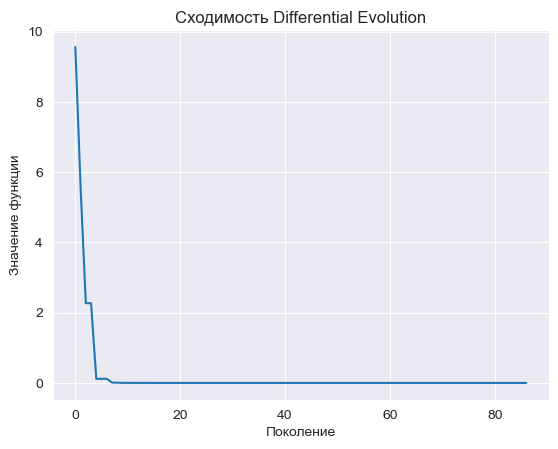

In [7]:
def plot_convergence():
    conv = []
    def callback(xk, convergence):
        conv.append(himmelblau(xk))
    differential_evolution(himmelblau, bounds, callback=callback)
    plt.plot(conv)
    plt.title("Сходимость Differential Evolution")
    plt.xlabel("Поколение")
    plt.ylabel("Значение функции")
    plt.grid(True)
    plt.show()

plot_convergence()

In [8]:
df = pd.DataFrame({
    "Алгоритм": ["BFGS", "Differential Evolution"],
    "Среднее значение": [np.mean(bfgs_vals), np.mean(de_vals)],
    "Дисперсия значения": [np.var(bfgs_vals), np.var(de_vals)],
    "Среднее время": [np.mean(bfgs_times), np.mean(de_times)],
    "Дисперсия времени": [np.var(bfgs_times), np.var(de_times)]
})
df

,Алгоритм,Среднее значение,Дисперсия значения,Среднее время,Дисперсия времени
0,BFGS,1.346976e-13,8.886618e-26,0.002650,3.904371e-07
1,Differential Evolution,4.709500e-30,2.367801e-59,0.144516,2.947423e-04
